# Notebook 05: Robustness and Generalization Analysis

This notebook evaluates the robustness and generalization properties of the explored predictive pipelines. It focuses on how performance changes across validation strategies, dataset variants, and random seeds, and identifies configurations that are not only strong but also stable and transferable across experimental conditions.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid", context="talk")

TABLE_DIR = Path("/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_tables")
FIG_DIR = Path("/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/05_robustness_generalization")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(TABLE_DIR / "results_seed_level.csv")
print(df.shape)
df.head()


(2000588, 34)


,dataset_variant,config_name,run_id,combo_id,val_strategy,seed,threshold,model_key,model_class,model_params,...,roc_auc,pr_auc,mcc,brier,accuracy,balanced_accuracy,precision,recall,f1,loo_metric_source
0,IMPUTED,config_kfold,20260202_032849,1,kfold,4.781633e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.803034,0.659453,0.411356,0.151723,0.78750,0.681884,0.658889,0.450000,0.507512,reported_fold_mean
1,IMPUTED,config_kfold,20260202_032849,2,kfold,1.122457e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.820018,0.680020,0.423810,0.148044,0.78750,0.676510,0.707302,0.430556,0.518162,reported_fold_mean
2,IMPUTED,config_kfold,20260202_032849,3,kfold,1.988882e+08,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.825377,0.663983,0.462220,0.143389,0.80000,0.700302,0.732698,0.477778,0.545664,reported_fold_mean
3,IMPUTED,config_kfold,20260202_032849,4,kfold,1.648071e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.814538,0.679425,0.481473,0.148196,0.80625,0.717995,0.697619,0.522222,0.595462,reported_fold_mean
4,IMPUTED,config_kfold,20260202_032849,5,kfold,2.013804e+09,0.5,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",...,0.801283,0.652545,0.335151,0.154048,0.75625,0.649577,0.586508,0.411111,0.457560,reported_fold_mean


In [5]:
# Basic checks
required_cols = [
    "dataset_variant", "config_name", "model_class", "scaler", "resampling", "pca",
    "seed", "mcc", "balanced_accuracy", "f1", "accuracy", "precision", "recall"
]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

for col in ["dataset_variant", "config_name", "model_class", "scaler", "resampling", "pca"]:
    df[col] = df[col].astype(str)

df["pipeline_id"] = (
    df["dataset_variant"].astype(str) + " | " +
    df["config_name"].astype(str) + " | " +
    df["model_class"].astype(str) + " | " +
    df["scaler"].astype(str) + " | " +
    df["resampling"].astype(str) + " | " +
    df["pca"].astype(str)
)

metric_cols = ["mcc", "balanced_accuracy", "f1", "accuracy", "precision", "recall"]
coverage = df.groupby("config_name")[metric_cols].agg(lambda s: s.notna().mean())
coverage


,mcc,balanced_accuracy,f1,accuracy,precision,recall
config_name,,,,,,
config_kfold,1.000000,1.0,1.0,1.0,1.000000,1.0
config_loo,0.995501,1.0,1.0,1.0,0.995501,1.0
config_random80,1.000000,1.0,1.0,1.0,1.000000,1.0
config_strat80,1.000000,1.0,1.0,1.0,1.000000,1.0


## 1. Robustness across validation strategies

The first step is to quantify how much performance varies as a function of the validation scheme. This is critical to determine whether apparently strong configurations are robust to different evaluation protocols or whether they are highly dependent on a specific split design.


In [6]:
validation_summary = (
    df.groupby("config_name")[metric_cols]
      .agg(["mean", "std", "median", "count"])
)

validation_summary.to_csv(TABLE_DIR / "validation_strategy_summary.csv")
validation_summary.head()


mcc                             balanced_accuracy  \
                     mean       std    median   count              mean   
config_name                                                               
config_kfold     0.394653  0.093612  0.401234  944152          0.704195   
config_loo       0.384025  0.090927  0.388371   39610          0.702246   
config_random80  0.382871  0.173111  0.382971  504927          0.707333   
config_strat80   0.395422  0.174881  0.407550  511720          0.701910   

                                                   f1            ...  \
                      std    median   count      mean       std  ...   
config_name                                                      ...   
config_kfold     0.052439  0.707594  944152  0.560954  0.087196  ...   
config_loo       0.054652  0.705975   39789  0.562873  0.084140  ...   
config_random80  0.095217  0.710227  504927  0.540965  0.140021  ...   
config_strat80   0.091174  0.702899  511720  0.570809  0.131556  ...   

                 accuracy         precision                              \
                   median   count      mean       std    median   count   
config_name                                                               
config_kfold     0.730115  944152  0.524351  0.085993  0.525653  944152   
config_loo       0.725000   39789  0.511672  0.072495  0.508475   39610   
config_random80  0.718750  504927  0.485602  0.159397  0.500000  504927   
config_strat80   0.718750  511720  0.539933  0.154843  0.500000  511720   

                   recall                              
                     mean       std    median   count  
config_name                                            
config_kfold     0.660792  0.145949  0.680000  944152  
config_loo       0.661476  0.147522  0.681818   39789  
config_random80  0.679805  0.209492  0.700000  504927  
config_strat80   0.658319  0.200227  0.666667  511720  

[4 rows x 24 columns]

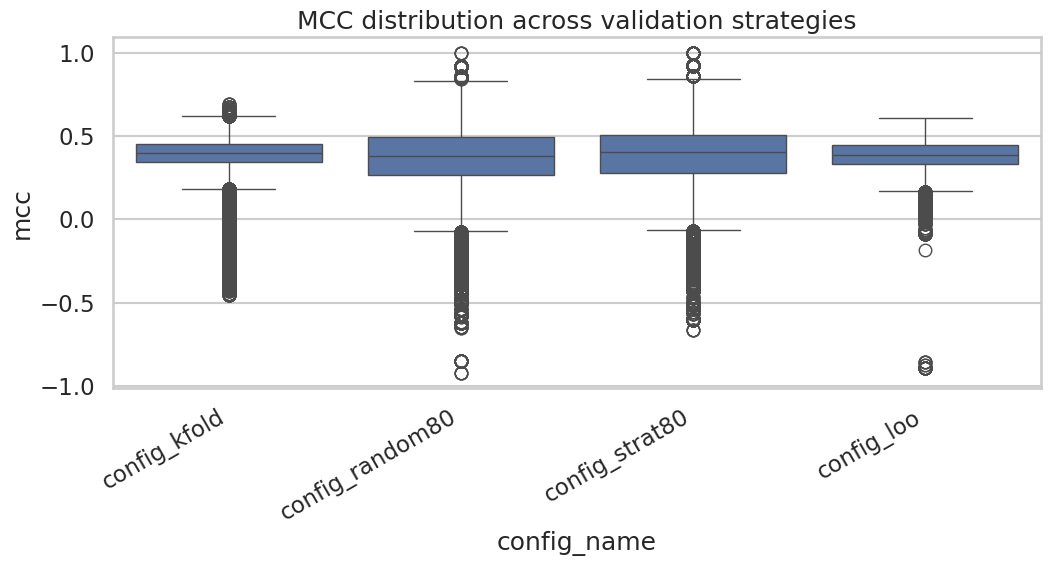

In [7]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="config_name", y="mcc")
plt.title("MCC distribution across validation strategies")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "mcc_by_validation_strategy.png", dpi=300, bbox_inches="tight")
plt.show()


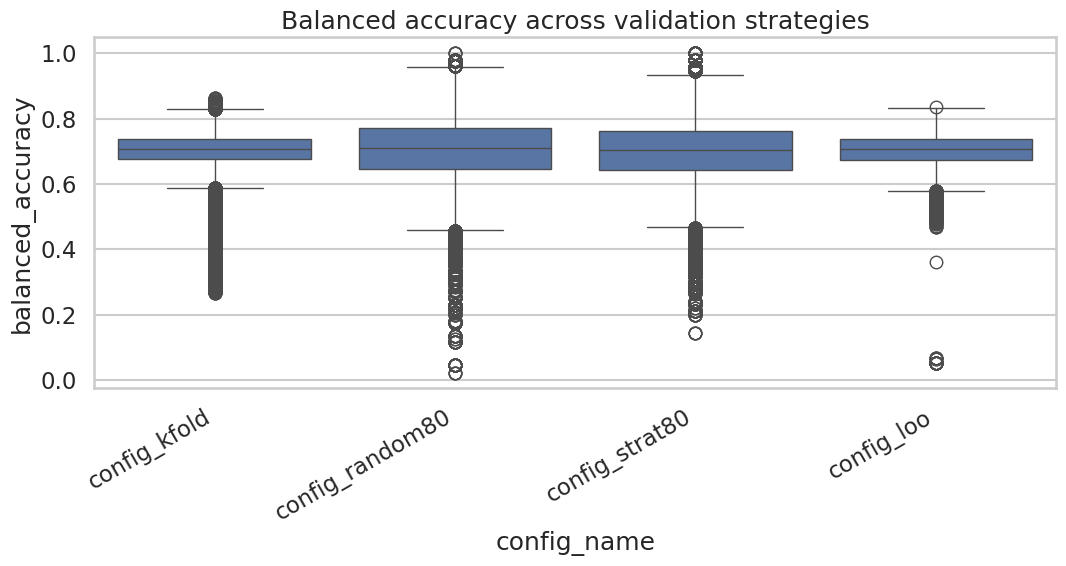

In [8]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="config_name", y="balanced_accuracy")
plt.title("Balanced accuracy across validation strategies")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "balanced_accuracy_by_validation_strategy.png", dpi=300, bbox_inches="tight")
plt.show()


In [9]:
# Robustness score per validation strategy
validation_robustness = (
    df.groupby("config_name")["mcc"]
      .agg(["mean", "std", "count"])
      .reset_index()
)
validation_robustness["cv_ratio"] = validation_robustness["std"] / validation_robustness["mean"].replace(0, np.nan)
validation_robustness = validation_robustness.sort_values(["mean", "std"], ascending=[False, True])

validation_robustness.to_csv(TABLE_DIR / "validation_robustness.csv", index=False)
validation_robustness


,config_name,mean,std,count,cv_ratio
3,config_strat80,0.395422,0.174881,511720,0.442264
0,config_kfold,0.394653,0.093612,944152,0.237202
1,config_loo,0.384025,0.090927,39610,0.236773
2,config_random80,0.382871,0.173111,504927,0.452138


## 2. Sensitivity to dataset variant

A core question of the study is whether model behavior changes substantially depending on the way missingness is handled. Here we compare the strict complete-case and imputed dataset variants, both globally and within matched pipeline configurations.


In [10]:
dataset_summary = (
    df.groupby("dataset_variant")[metric_cols]
      .agg(["mean", "std", "median", "count"])
)

dataset_summary.to_csv(TABLE_DIR / "dataset_variant_summary.csv")
dataset_summary


mcc                              balanced_accuracy  \
                     mean       std    median    count              mean   
dataset_variant                                                            
IMPUTED          0.393629  0.144827  0.394815   983978          0.706959   
STRICT           0.389765  0.135976  0.400066  1016431          0.701852   

                                                    f1            ...  \
                      std    median    count      mean       std  ...   
dataset_variant                                                   ...   
IMPUTED          0.078994  0.708333   984040  0.557113  0.117177  ...   
STRICT           0.072891  0.706349  1016548  0.559780  0.112826  ...   

                 accuracy          precision                               \
                   median    count      mean       std    median    count   
dataset_variant                                                             
IMPUTED          0.725000   984040  0.512097  0.128823  0.500000   983978   
STRICT           0.730575  1016548  0.524315  0.128177  0.528485  1016431   

                   recall                               
                     mean       std    median    count  
dataset_variant                                         
IMPUTED          0.668783  0.181211  0.670000   984040  
STRICT           0.661283  0.175924  0.666667  1016548  

[2 rows x 24 columns]

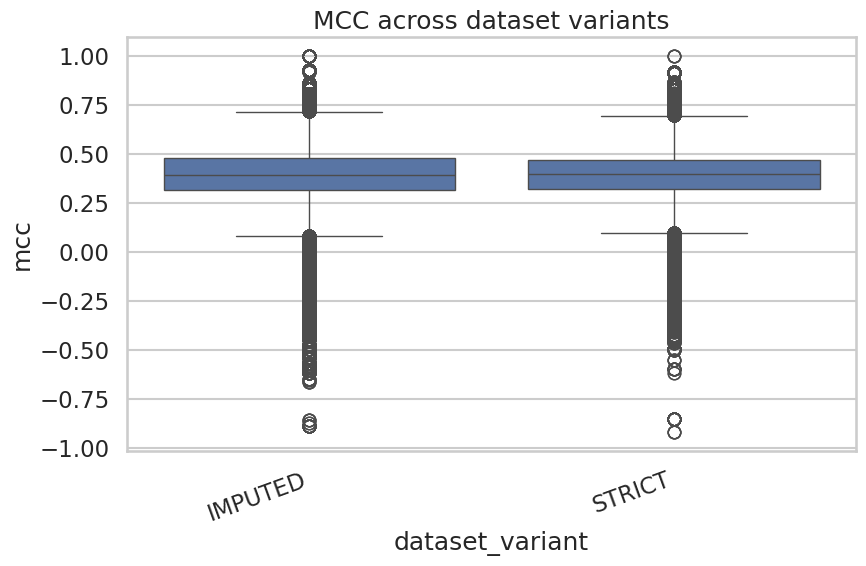

In [11]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="dataset_variant", y="mcc")
plt.title("MCC across dataset variants")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "mcc_by_dataset_variant.png", dpi=300, bbox_inches="tight")
plt.show()


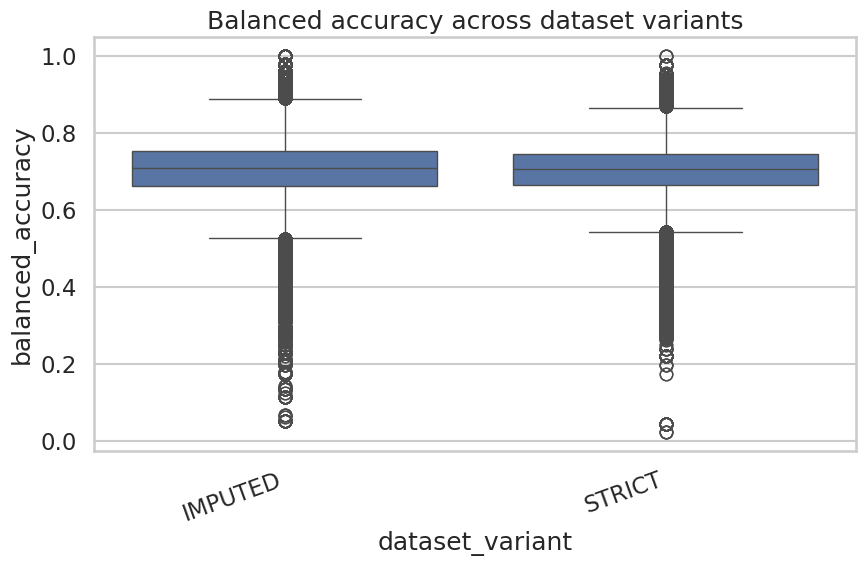

In [12]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="dataset_variant", y="balanced_accuracy")
plt.title("Balanced accuracy across dataset variants")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "balanced_accuracy_by_dataset_variant.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
# Matched comparison between dataset variants using the same pipeline structure
match_cols = ["config_name", "model_class", "scaler", "resampling", "pca", "seed"]

matched = (
    df.pivot_table(
        index=match_cols,
        columns="dataset_variant",
        values=metric_cols,
        aggfunc="mean"
    )
)

matched.columns = ["__".join(map(str, c)) for c in matched.columns]
matched = matched.reset_index()

mcc_variant_cols = [c for c in matched.columns if c.startswith("mcc__")]
ba_variant_cols = [c for c in matched.columns if c.startswith("balanced_accuracy__")]

matched.head()


,config_name,model_class,scaler,resampling,pca,seed,accuracy__IMPUTED,accuracy__STRICT,balanced_accuracy__IMPUTED,balanced_accuracy__STRICT,f1__IMPUTED,f1__STRICT,mcc__IMPUTED,mcc__STRICT,precision__IMPUTED,precision__STRICT,recall__IMPUTED,recall__STRICT
0,config_kfold,GaussianNB,maxabs,none,off,198888238.0,0.78750,0.743859,0.736894,0.674702,0.615556,0.524520,0.476102,0.368893,0.626667,0.578512,0.620000,0.512500
1,config_kfold,GaussianNB,maxabs,none,off,330267354.0,0.76250,0.762529,0.706520,0.725072,0.574597,0.606536,0.432090,0.439866,0.620359,0.580000,0.585833,0.638889
2,config_kfold,GaussianNB,maxabs,none,off,478163327.0,0.76875,0.729475,0.711534,0.682372,0.576541,0.534237,0.427334,0.366884,0.588312,0.548098,0.586111,0.566389
3,config_kfold,GaussianNB,maxabs,none,off,505971449.0,0.76250,0.739228,0.718197,0.686203,0.589446,0.549458,0.435123,0.386165,0.587103,0.576511,0.616944,0.569722
4,config_kfold,GaussianNB,maxabs,none,off,624025999.0,0.75625,0.749828,0.696894,0.703712,0.554978,0.566574,0.402005,0.412415,0.576667,0.589383,0.565000,0.590000


In [14]:
# Compute pairwise deltas if exactly two dataset variants are available
dataset_variants = sorted(df["dataset_variant"].dropna().unique().tolist())
dataset_deltas = None

if len(dataset_variants) == 2:
    d1, d2 = dataset_variants
    dataset_deltas = matched.copy()
    dataset_deltas["delta_mcc"] = dataset_deltas[f"mcc__{d2}"] - dataset_deltas[f"mcc__{d1}"]
    dataset_deltas["delta_balanced_accuracy"] = (
        dataset_deltas[f"balanced_accuracy__{d2}"] - dataset_deltas[f"balanced_accuracy__{d1}"]
    )
    dataset_deltas.to_csv(TABLE_DIR / "dataset_variant_deltas.csv", index=False)
    display(dataset_deltas[match_cols + ["delta_mcc", "delta_balanced_accuracy"]].head())
else:
    print("Dataset delta table skipped because the number of dataset variants is not equal to 2.")


,config_name,model_class,scaler,resampling,pca,seed,delta_mcc,delta_balanced_accuracy
0,config_kfold,GaussianNB,maxabs,none,off,198888238.0,-0.107209,-0.062192
1,config_kfold,GaussianNB,maxabs,none,off,330267354.0,0.007777,0.018552
2,config_kfold,GaussianNB,maxabs,none,off,478163327.0,-0.060450,-0.029162
3,config_kfold,GaussianNB,maxabs,none,off,505971449.0,-0.048958,-0.031994
4,config_kfold,GaussianNB,maxabs,none,off,624025999.0,0.010410,0.006818


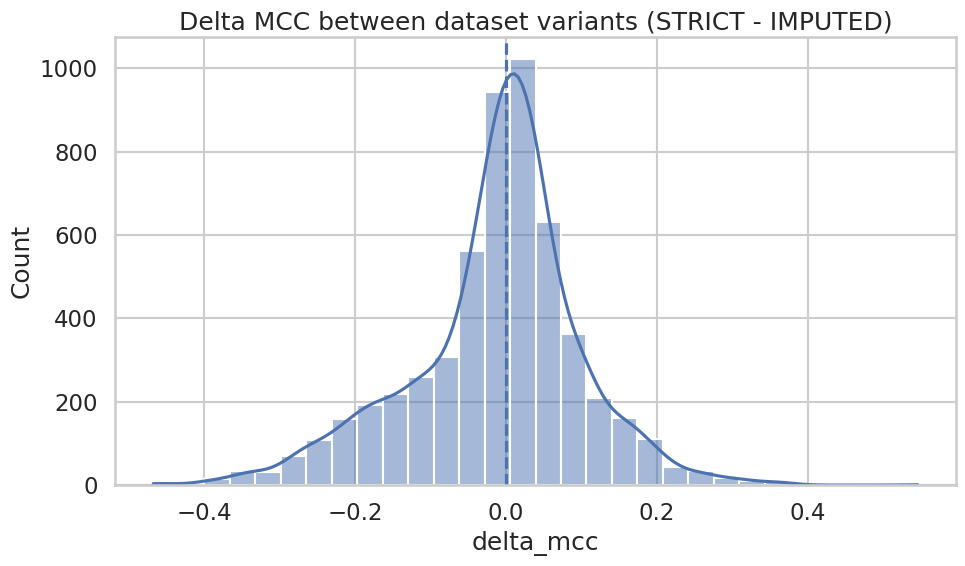

In [15]:
if dataset_deltas is not None:
    plt.figure(figsize=(10, 6))
    sns.histplot(dataset_deltas["delta_mcc"].dropna(), bins=30, kde=True)
    plt.axvline(0, linestyle="--")
    plt.title(f"Delta MCC between dataset variants ({dataset_variants[1]} - {dataset_variants[0]})")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "delta_mcc_dataset_variants.png", dpi=300, bbox_inches="tight")
    plt.show()


## 3. Stability across random seeds

To move beyond average performance, we quantify the extent to which each pipeline remains stable across stochastic repetitions. This allows us to identify configurations that perform well on average but are unstable, as well as pipelines that are slightly less accurate but more reproducible.


In [16]:
seed_stability = (
    df.groupby(["dataset_variant", "config_name", "model_class", "scaler", "resampling", "pca"])["mcc"]
      .agg(["mean", "std", "median", "min", "max", "count"])
      .reset_index()
)
seed_stability["range"] = seed_stability["max"] - seed_stability["min"]
seed_stability["cv_ratio"] = seed_stability["std"] / seed_stability["mean"].replace(0, np.nan)

seed_stability = seed_stability.sort_values(["mean", "std"], ascending=[False, True])
seed_stability.to_csv(TABLE_DIR / "seed_stability_summary.csv", index=False)
seed_stability.head(20)


,dataset_variant,config_name,model_class,scaler,resampling,pca,mean,std,median,min,max,count,range,cv_ratio
720,IMPUTED,config_strat80,SVC,robust,smote,off,0.564179,0.172716,0.571635,0.132619,1.000000,480,0.867381,0.306137
648,IMPUTED,config_strat80,LogisticRegression,robust,smote,off,0.562464,0.173211,0.571635,0.089730,1.000000,480,0.910270,0.307950
728,IMPUTED,config_strat80,SVC,standard,smote,off,0.559993,0.175007,0.569191,0.132619,1.000000,480,0.867381,0.312517
729,IMPUTED,config_strat80,SVC,standard,smote,on,0.556998,0.172693,0.569191,0.132619,1.000000,3360,0.867381,0.310042
656,IMPUTED,config_strat80,LogisticRegression,standard,smote,off,0.554603,0.172395,0.569191,0.132619,0.927831,480,0.795211,0.310844
608,IMPUTED,config_strat80,LinearDiscriminantAnalysis,maxabs,smote,off,0.553450,0.178322,0.593180,0.178068,0.927831,80,0.749762,0.322201
628,IMPUTED,config_strat80,LinearDiscriminantAnalysis,standard,smote,off,0.550009,0.187299,0.547925,0.178068,0.927831,80,0.749762,0.340538
643,IMPUTED,config_strat80,LogisticRegression,none,smote,off,0.549983,0.165168,0.569191,0.132619,0.922958,480,0.790339,0.300316
657,IMPUTED,config_strat80,LogisticRegression,standard,smote,on,0.543917,0.164758,0.526660,0.132619,0.927831,3360,0.795211,0.302910
642,IMPUTED,config_strat80,LogisticRegression,none,none,off,0.543736,0.159801,0.543955,0.178068,0.927831,120,0.749762,0.293894


In [17]:
# Stable high-performing configurations
stable_high_perf = seed_stability[
    (seed_stability["count"] >= 2) &
    (seed_stability["mean"] >= seed_stability["mean"].quantile(0.75))
].sort_values(["std", "mean"], ascending=[True, False])

stable_high_perf.to_csv(TABLE_DIR / "stable_high_performing_configurations.csv", index=False)
stable_high_perf.head(20)


,dataset_variant,config_name,model_class,scaler,resampling,pca,mean,std,median,min,max,count,range,cv_ratio
972,STRICT,config_loo,LinearDiscriminantAnalysis,maxabs,none,off,0.486265,0.000000,0.486265,0.486265,0.486265,2,0.000000,0.000000
980,STRICT,config_loo,LinearDiscriminantAnalysis,none,none,off,0.486265,0.000000,0.486265,0.486265,0.486265,2,0.000000,0.000000
984,STRICT,config_loo,LinearDiscriminantAnalysis,robust,none,off,0.486265,0.000000,0.486265,0.486265,0.486265,2,0.000000,0.000000
992,STRICT,config_loo,LinearDiscriminantAnalysis,standard,none,off,0.486265,0.000000,0.486265,0.486265,0.486265,2,0.000000,0.000000
238,IMPUTED,config_loo,LinearDiscriminantAnalysis,maxabs,none,off,0.453110,0.000000,0.453110,0.453110,0.453110,2,0.000000,0.000000
246,IMPUTED,config_loo,LinearDiscriminantAnalysis,none,none,off,0.453110,0.000000,0.453110,0.453110,0.453110,2,0.000000,0.000000
250,IMPUTED,config_loo,LinearDiscriminantAnalysis,robust,none,off,0.453110,0.000000,0.453110,0.453110,0.453110,2,0.000000,0.000000
258,IMPUTED,config_loo,LinearDiscriminantAnalysis,standard,none,off,0.453110,0.000000,0.453110,0.453110,0.453110,2,0.000000,0.000000
200,IMPUTED,config_loo,GaussianNB,robust,undersample,off,0.447929,0.000000,0.447929,0.447929,0.447929,3,0.000000,0.000000
208,IMPUTED,config_loo,GaussianNB,standard,undersample,off,0.447929,0.000000,0.447929,0.447929,0.447929,3,0.000000,0.000000


/tmp/ipykernel_45019/226851590.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


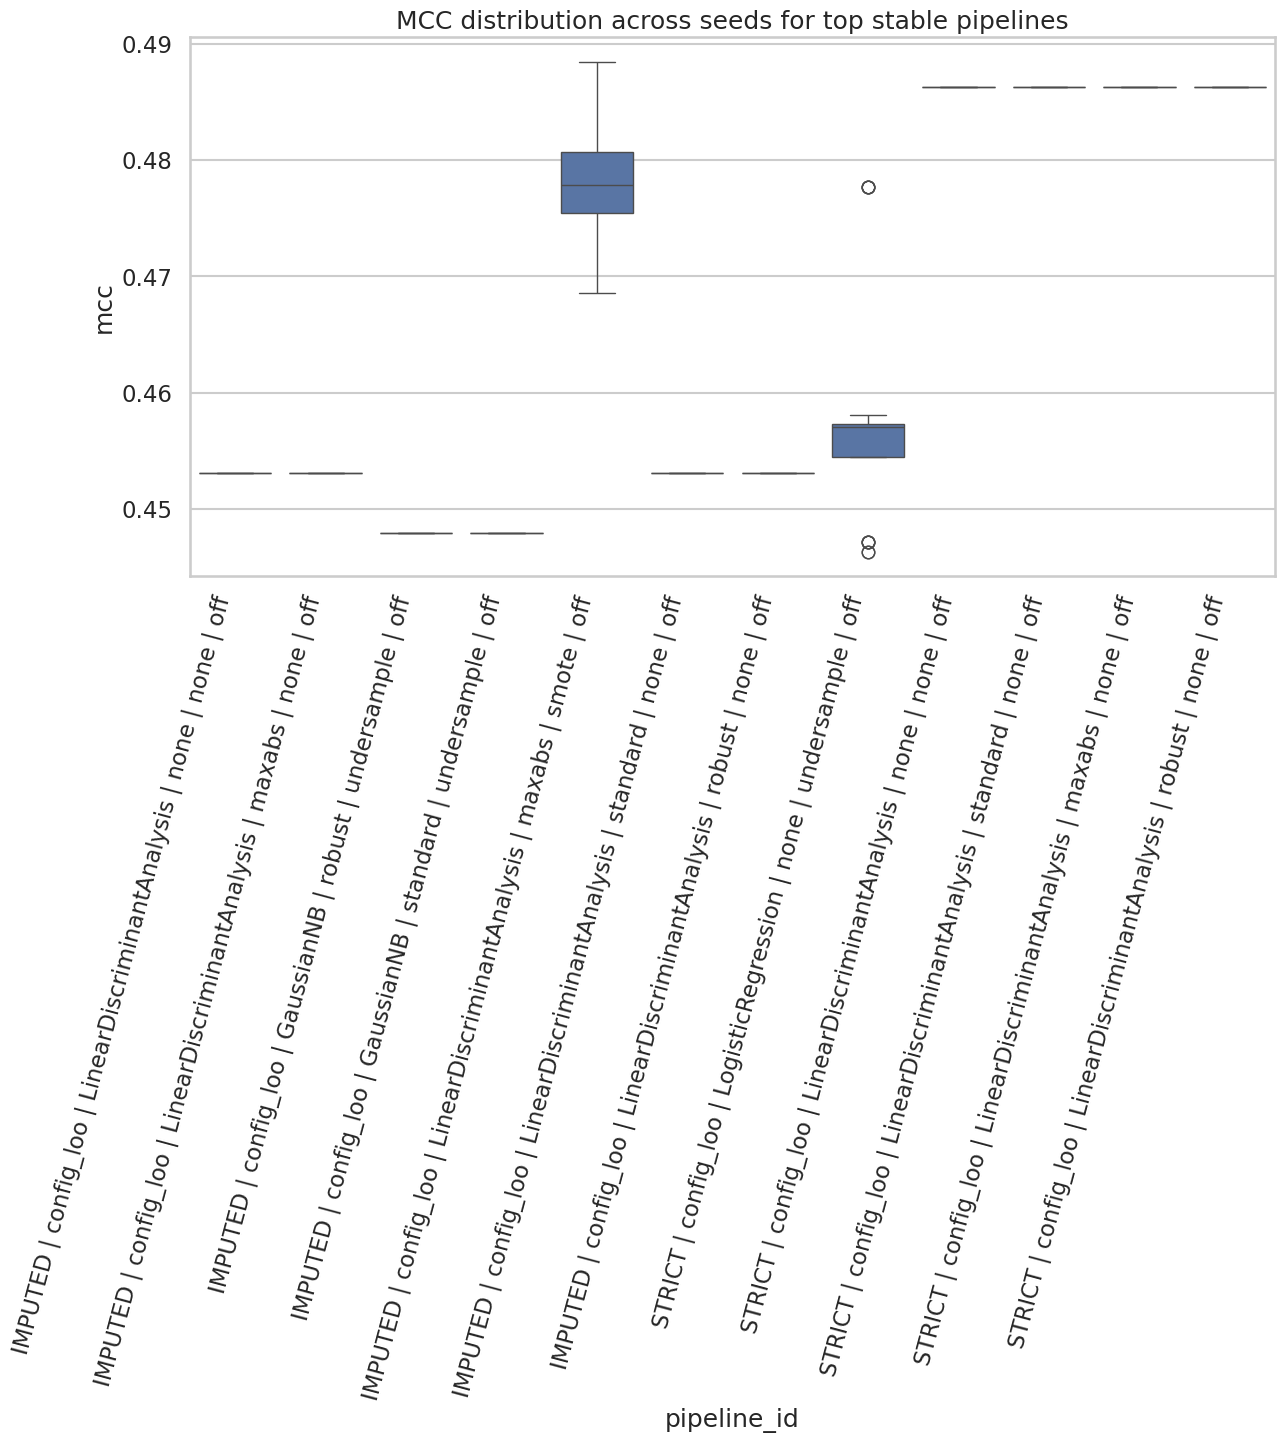

In [18]:
top_pipelines = stable_high_perf.head(12).copy()

if not top_pipelines.empty:
    top_ids = set(
        top_pipelines.apply(
            lambda r: f"{r['dataset_variant']} | {r['config_name']} | {r['model_class']} | {r['scaler']} | {r['resampling']} | {r['pca']}",
            axis=1
        )
    )
    plot_df = df[df["pipeline_id"].isin(top_ids)].copy()

    plt.figure(figsize=(14, 7))
    sns.boxplot(data=plot_df, x="pipeline_id", y="mcc")
    plt.title("MCC distribution across seeds for top stable pipelines")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "mcc_across_seeds_top_stable_pipelines.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No stable high-performing pipelines matched the current filters.")


## 4. Generalization profile of top configurations

This section identifies the strongest pipeline families and evaluates whether they remain competitive across different validation schemes and dataset variants. The aim is to move from isolated wins to robust families of configurations.


In [19]:
generalization_profile = (
    df.groupby(["dataset_variant", "config_name", "model_class", "scaler", "resampling", "pca"])[metric_cols]
      .agg(["mean", "std", "count"])
)

generalization_profile.to_csv(TABLE_DIR / "generalization_profile.csv")
generalization_profile.head()


mcc  \
                                                                    mean   
dataset_variant config_name  model_class scaler resampling pca             
IMPUTED         config_kfold GaussianNB  maxabs none       off  0.413071   
                                                           on   0.283622   
                                                smote      off  0.371348   
                                                           on   0.385133   
                                                smoteenn   off  0.376680   

                                                                          \
                                                                     std   
dataset_variant config_name  model_class scaler resampling pca             
IMPUTED         config_kfold GaussianNB  maxabs none       off  0.035367   
                                                           on   0.063383   
                                                smote      off  0.031772   
                                                           on   0.048681   
                                                smoteenn   off  0.042548   

                                                                      \
                                                               count   
dataset_variant config_name  model_class scaler resampling pca         
IMPUTED         config_kfold GaussianNB  maxabs none       off    84   
                                                           on    588   
                                                smote      off   336   
                                                           on   2352   
                                                smoteenn   off   336   

                                                               balanced_accuracy  \
                                                                            mean   
dataset_variant config_name  model_class scaler resampling pca                     
IMPUTED         config_kfold GaussianNB  maxabs none       off          0.705496   
                                                           on           0.622667   
                                                smote      off          0.697087   
                                                           on           0.703534   
                                                smoteenn   off          0.699519   

                                                                          \
                                                                     std   
dataset_variant config_name  model_class scaler resampling pca             
IMPUTED         config_kfold GaussianNB  maxabs none       off  0.016230   
                                                           on   0.028133   
                                                smote      off  0.016222   
                                                           on   0.026797   
                                                smoteenn   off  0.022483   

                                                                      \
                                                               count   
dataset_variant config_name  model_class scaler resampling pca         
IMPUTED         config_kfold GaussianNB  maxabs none       off    84   
                                                           on    588   
                                                smote      off   336   
                                                           on   2352   
                                                smoteenn   off   336   

                                                                      f1  \
                                                                    mean   
dataset_variant config_name  model_class scaler resampling pca             
IMPUTED         config_kfold GaussianNB  maxabs none       off  0.566600   
                                                           on   0.416707   
                                   

In [20]:
# Build a compact generalization score based on central performance and variability
gen_score = (
    df.groupby(["dataset_variant", "config_name", "model_class", "scaler", "resampling", "pca"])["mcc"]
      .agg(["mean", "std", "count"])
      .reset_index()
)
gen_score["generalization_score"] = gen_score["mean"] - gen_score["std"].fillna(0)
gen_score = gen_score.sort_values("generalization_score", ascending=False)

gen_score.to_csv(TABLE_DIR / "generalization_score_ranking.csv", index=False)
gen_score.head(20)


,dataset_variant,config_name,model_class,scaler,resampling,pca,mean,std,count,generalization_score
972,STRICT,config_loo,LinearDiscriminantAnalysis,maxabs,none,off,0.486265,0.000000,2,0.486265
992,STRICT,config_loo,LinearDiscriminantAnalysis,standard,none,off,0.486265,0.000000,2,0.486265
984,STRICT,config_loo,LinearDiscriminantAnalysis,robust,none,off,0.486265,0.000000,2,0.486265
980,STRICT,config_loo,LinearDiscriminantAnalysis,none,none,off,0.486265,0.000000,2,0.486265
289,IMPUTED,config_loo,LogisticRegression,standard,smote,on,0.498129,0.024706,336,0.473422
1023,STRICT,config_loo,LogisticRegression,standard,smote,on,0.506950,0.034377,336,0.472574
240,IMPUTED,config_loo,LinearDiscriminantAnalysis,maxabs,smote,off,0.478210,0.007528,8,0.470682
1022,STRICT,config_loo,LogisticRegression,standard,smote,off,0.493194,0.022612,48,0.470582
107,IMPUTED,config_kfold,LogisticRegression,standard,smote,on,0.508581,0.039668,6720,0.468914
995,STRICT,config_loo,LinearDiscriminantAnalysis,standard,smote,on,0.500794,0.036114,56,0.464680


/tmp/ipykernel_45019/3862839059.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


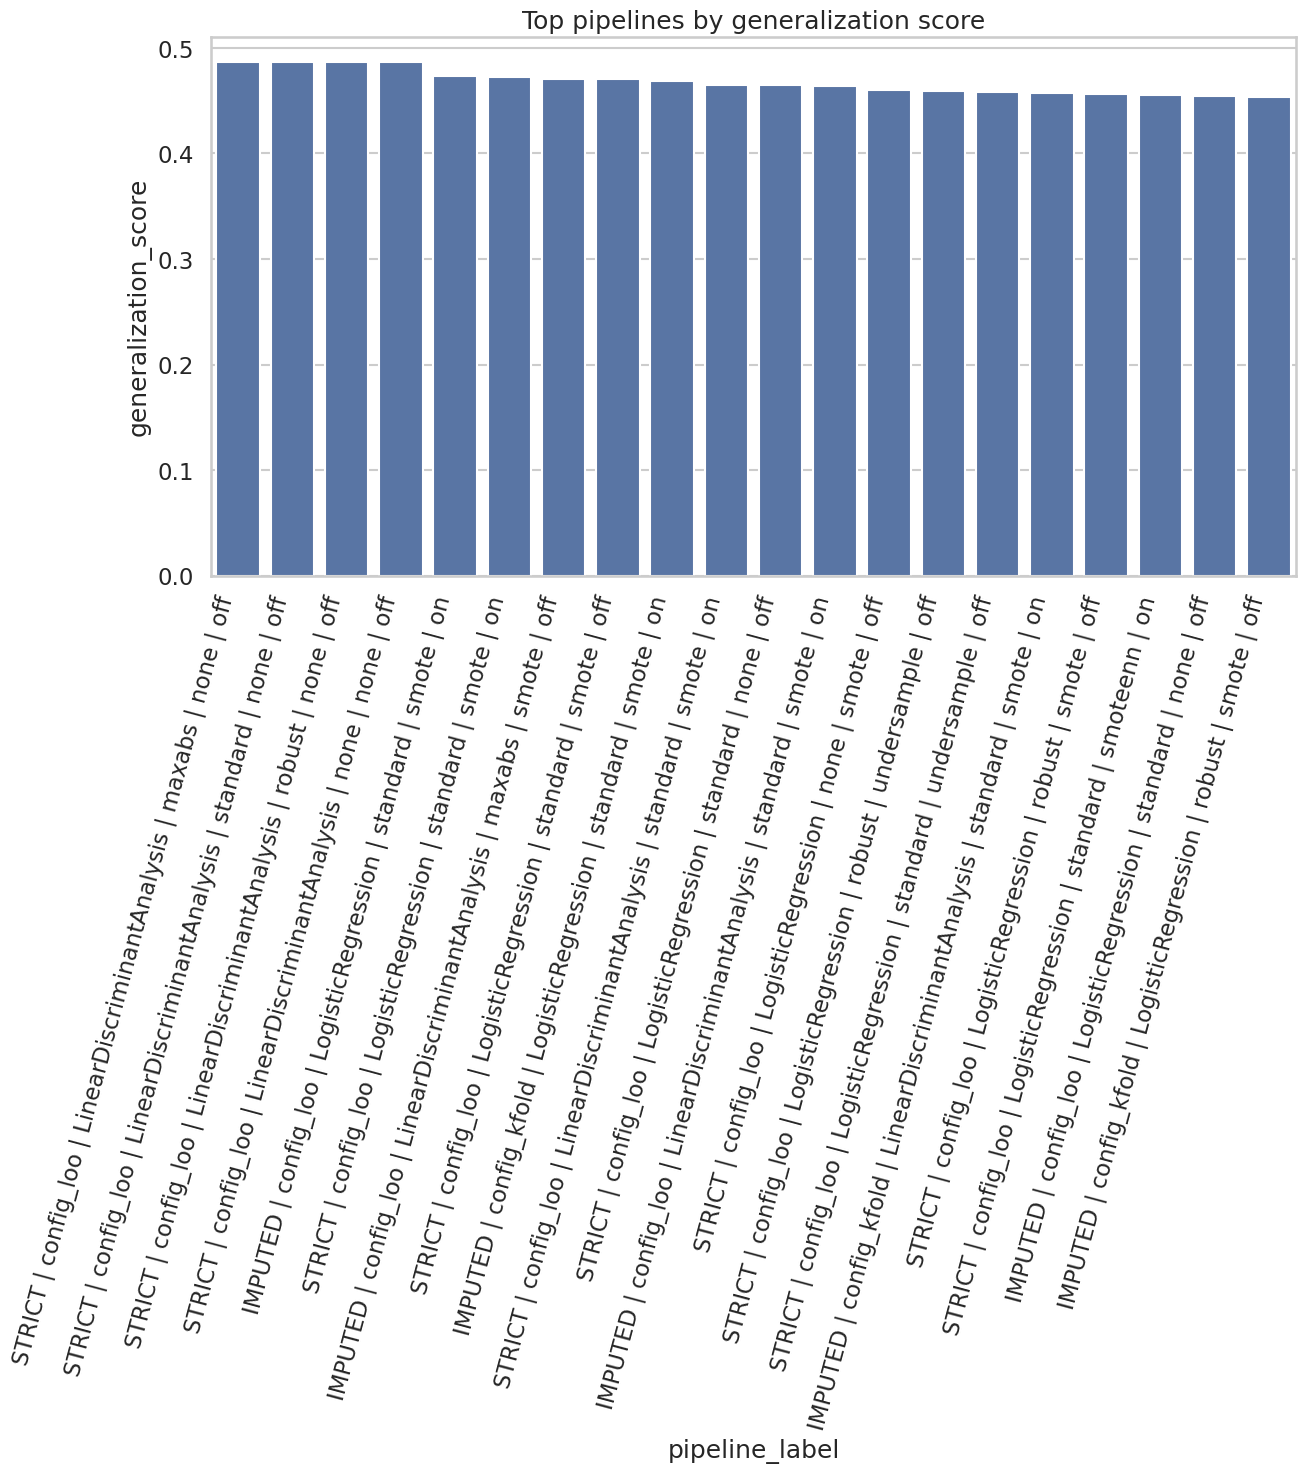

In [21]:
top_gen = gen_score.head(20).copy()
top_gen["pipeline_label"] = (
    top_gen["dataset_variant"] + " | " + top_gen["config_name"] + " | " +
    top_gen["model_class"] + " | " + top_gen["scaler"] + " | " +
    top_gen["resampling"] + " | " + top_gen["pca"]
)

plt.figure(figsize=(14, 7))
sns.barplot(data=top_gen, x="pipeline_label", y="generalization_score")
plt.title("Top pipelines by generalization score")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_generalization_score_pipelines.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Cross-strategy consistency of model families

Finally, we examine whether some model classes are systematically more stable than others across evaluation regimes and dataset variants. This provides a family-level view of robustness that is useful for methodological recommendations.


In [22]:
model_family_summary = (
    df.groupby("model_class")[metric_cols]
      .agg(["mean", "std", "median", "count"])
)

model_family_summary.to_csv(TABLE_DIR / "model_family_summary.csv")
model_family_summary


mcc                              \
                                   mean       std    median   count   
model_class                                                           
GaussianNB                     0.387754  0.135442  0.389268  119378   
KNeighborsClassifier           0.357418  0.124060  0.362702  720136   
LinearDiscriminantAnalysis     0.455172  0.128282  0.462910   45100   
LogisticRegression             0.455339  0.147346  0.477699  270548   
QuadraticDiscriminantAnalysis  0.328378  0.145166  0.339306  135220   
RandomForestClassifier         0.398648  0.112625  0.402847  458411   
SVC                            0.432982  0.175700  0.462910  251616   

                              balanced_accuracy                              \
                                           mean       std    median   count   
model_class                                                                   
GaussianNB                             0.700533  0.071325  0.702500  119378   
KNeighborsClassifier                   0.688429  0.067128  0.690476  720136   
LinearDiscriminantAnalysis             0.740338  0.070260  0.744318   45100   
LogisticRegression                     0.742822  0.081975  0.755682  270600   
QuadraticDiscriminantAnalysis          0.666510  0.079440  0.671498  135300   
RandomForestClassifier                 0.703100  0.058194  0.705530  458411   
SVC                                    0.726634  0.095438  0.745290  251663   

                                     f1            ...  accuracy          \
                                   mean       std  ...    median   count   
model_class                                        ...                     
GaussianNB                     0.554969  0.104290  ...  0.731250  119378   
KNeighborsClassifier           0.542821  0.091953  ...  0.702857  720136   
LinearDiscriminantAnalysis     0.606143  0.097600  ...  0.750000   45100   
LogisticRegression             0.601145  0.134651  ...  0.749655  270600   
QuadraticDiscriminantAnalysis  0.492608  0.151829  ...  0.718750  135300   
RandomForestClassifier         0.562241  0.083929  ...  0.737500  458411   
SVC                            0.579006  0.153262  ...  0.750000  251663   

                              precision                                recall  \
                                   mean       std    median   count      mean   
model_class                                                                     
GaussianNB                     0.528504  0.125824  0.519514  119378  0.636968   
KNeighborsClassifier           0.491107  0.106113  0.489057  720136  0.659201   
LinearDiscriminantAnalysis     0.549315  0.118672  0.544872   45100  0.734169   
LogisticRegression             0.531026  0.133831  0.539286  270548  0.753457   
QuadraticDiscriminantAnalysis  0.481399  0.159833  0.500000  135220  0.582946   
RandomForestClassifier         0.548587  0.117997  0.545455  458411  0.627758   
SVC                            0.536738  0.160293  0.548205  251616  0.699114   

                                                           
                                    std    median   count  
model_class                                                
GaussianNB                     0.159463  0.655000  119378  
KNeighborsClassifier           0.153898  0.666667  720136  
LinearDiscriminantAnalysis     0.158588  0.752778   45100  
LogisticRegression             0.194573  0.780000  270600  
QuadraticDiscriminantAnalysis  0.235899  0.600000  135300  
RandomForestClassifier         0.134705  0.630000  458411  
SVC                            0.220126  0.750000  251663  

[7 rows x 24 columns]

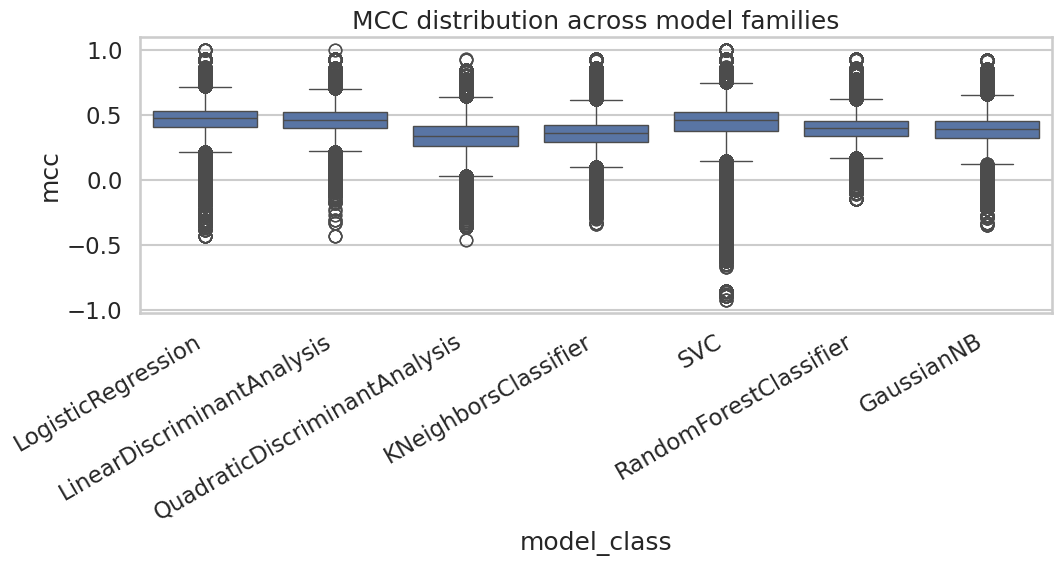

In [23]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="model_class", y="mcc")
plt.title("MCC distribution across model families")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "mcc_by_model_family.png", dpi=300, bbox_inches="tight")
plt.show()


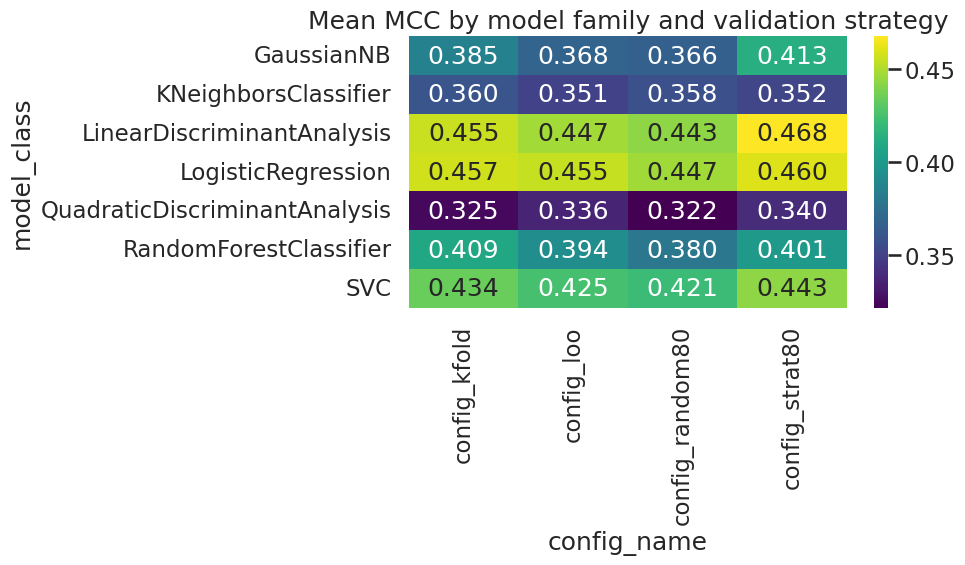

In [24]:
# Heatmap: mean MCC per model family and validation strategy
heatmap_model_validation = df.pivot_table(
    index="model_class",
    columns="config_name",
    values="mcc",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_model_validation, annot=True, fmt=".3f", cmap="viridis")
plt.title("Mean MCC by model family and validation strategy")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_model_family_by_validation.png", dpi=300, bbox_inches="tight")
plt.show()

heatmap_model_validation.to_csv(TABLE_DIR / "heatmap_model_family_by_validation.csv")


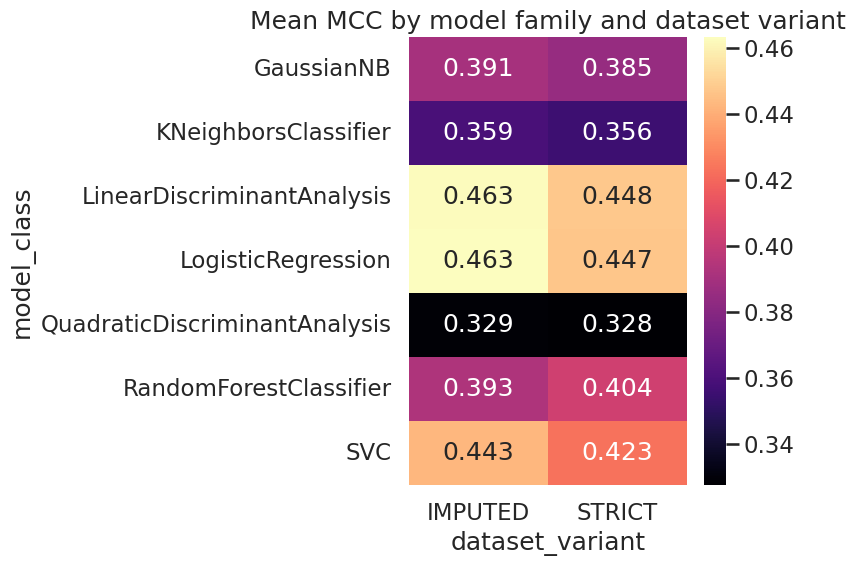

In [26]:
# Heatmap: mean MCC per model family and dataset variant
heatmap_model_dataset = df.pivot_table(
    index="model_class",
    columns="dataset_variant",
    values="mcc",
    aggfunc="mean"
)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_model_dataset, annot=True, fmt=".3f", cmap="magma")
plt.title("Mean MCC by model family and dataset variant")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_model_family_by_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

heatmap_model_dataset.to_csv(TABLE_DIR / "heatmap_model_family_by_dataset.csv")


## 6. Export compact summary tables for manuscript use

The following tables provide a concise synthesis of the main robustness and generalization outputs that can later be integrated into results, discussion, or supplementary material.


In [27]:
compact_summary = gen_score.merge(
    seed_stability[["dataset_variant", "config_name", "model_class", "scaler", "resampling", "pca", "range", "cv_ratio"]],
    on=["dataset_variant", "config_name", "model_class", "scaler", "resampling", "pca"],
    how="left"
)

compact_summary = compact_summary.sort_values(
    ["generalization_score", "mean", "std"],
    ascending=[False, False, True]
)

compact_summary.to_csv(TABLE_DIR / "robustness_generalization_compact_summary.csv", index=False)
compact_summary.head(25)


,dataset_variant,config_name,model_class,scaler,resampling,pca,mean,std,count,generalization_score,range,cv_ratio
0,STRICT,config_loo,LinearDiscriminantAnalysis,maxabs,none,off,0.486265,0.000000,2,0.486265,0.000000,0.000000
1,STRICT,config_loo,LinearDiscriminantAnalysis,standard,none,off,0.486265,0.000000,2,0.486265,0.000000,0.000000
2,STRICT,config_loo,LinearDiscriminantAnalysis,robust,none,off,0.486265,0.000000,2,0.486265,0.000000,0.000000
3,STRICT,config_loo,LinearDiscriminantAnalysis,none,none,off,0.486265,0.000000,2,0.486265,0.000000,0.000000
4,IMPUTED,config_loo,LogisticRegression,standard,smote,on,0.498129,0.024706,336,0.473422,0.126383,0.049598
5,STRICT,config_loo,LogisticRegression,standard,smote,on,0.506950,0.034377,336,0.472574,0.176357,0.067811
6,IMPUTED,config_loo,LinearDiscriminantAnalysis,maxabs,smote,off,0.478210,0.007528,8,0.470682,0.019894,0.015742
7,STRICT,config_loo,LogisticRegression,standard,smote,off,0.493194,0.022612,48,0.470582,0.081534,0.045847
8,IMPUTED,config_kfold,LogisticRegression,standard,smote,on,0.508581,0.039668,6720,0.468914,0.280421,0.077997
9,STRICT,config_loo,LinearDiscriminantAnalysis,standard,smote,on,0.500794,0.036114,56,0.464680,0.132994,0.072113


## Interpretation guide

A strong pipeline should ideally combine three properties: competitive central performance, low variability across seeds, and consistency across dataset variants and validation strategies. The outputs generated in this notebook are designed to identify such configurations and to distinguish them from pipelines whose apparent strength depends on a narrow or unstable evaluation context.
